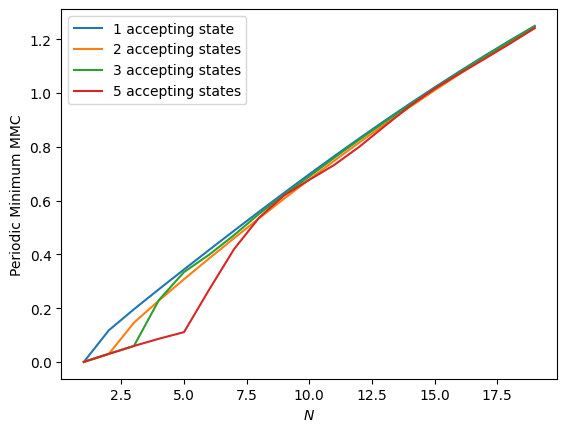

In [1]:
import numpy as np
from numpy.linalg import matrix_power
from scipy.stats import entropy
import matplotlib.pyplot as plt

def pop(p0, G, N):
    p_avg = np.zeros_like(p0, dtype=float)

    for t in range(N):
        p_avg += matrix_power(G, t) @ p0

    return p_avg / N


def pmmc(p0, G, N):
    p_avg = pop(p0, G, N)
    return (
        entropy(matrix_power(G, N) @ p0)
        - entropy(p0)
        + N * (entropy(p_avg) - entropy(G @ p_avg))
    )

# simple DFA

Ns = np.arange(1,20)

p=0.8

p0 = np.array([1, 0])
G = np.array([
    [p, 0],
    [1-p, 1],
])
simple_pmmc = np.array([pmmc(p0,G,N) for N in Ns])

p0 = np.array([1, 0, 0])
G = np.array([
    [p,   0,   0],
    [1-p, 1-p, 1-p],
    [0,   p,   p]
])
extra_pmmc = np.array([pmmc(p0,G,N) for N in Ns])

p0 = np.array([1, 0, 0, 0])
G = np.array([
    [p,   0,   0,   0],
    [1-p, 1-p, 0,   p],
    [0,   p,   1-p, 0],
    [0,   0,   p,   1-p]
])
four_state_pmmc = [pmmc(p0, G, N) for N in Ns]

p0 = np.array([1, 0, 0, 0, 0, 0])

G = np.array([
    [p,   0,   0,   0,   0,   0],
    [1-p, 1-p, 0,   0,   0,   p],
    [0,   p,   1-p, 0,   0,   0],
    [0,   0,   p,   1-p, 0,   0],
    [0,   0,   0,   p,   1-p, 0],
    [0,   0,   0,   0,   p,   1-p]
])

five_state_pmmc = np.array([
    pmmc(p0, G, N)
    for N in Ns
])

plt.plot(Ns, simple_pmmc, label="1 accepting state")
plt.plot(Ns, extra_pmmc, label="2 accepting states")
plt.plot(Ns, four_state_pmmc, label="3 accepting states")
plt.plot(Ns, five_state_pmmc, label="5 accepting states")

plt.xlabel("$N$")
plt.ylabel("Periodic Minimum MMC")
plt.legend()
plt.show()


In [ ]:
import numpy as np

# Probability of reading a 0
p = 0.5
q = 1 - p

# 20-state DFA

n = 20
G20 = np.zeros((n, n))

# States:
# 0-4   : A1-A5
# 5-9   : B1-B5
# 10-14 : C1-C5
# 15-19 : D1-D5

for i in range(5):
  nxt = (i + 1) % 5

  # ---------- A ----------
  G20[nxt, i] += p            # A_i --0--> A_{i+1}
  G20[5 + nxt, i] += q          # A_i --1--> B_{i+1}

  # ---------- B ----------
  G20[10 + nxt, 5 + i] += p       # B_i --0--> C_{i+1}
  G20[5 + nxt, 5 + i] += q        # B_i --1--> B_{i+1}

  # ---------- C ----------
  G20[nxt, 10 + i] += p         # C_i --0--> A_{i+1}
  G20[15 + nxt, 10 + i] += q      # C_i --1--> D_{i+1}

  # ---------- D ----------
  G20[15 + i, 15 + i] += p      # D_i --0--> D_{i+1}
  G20[15 + i, 15 + i] += q      # D_i --1--> D_{i+1}


A, B, C, D = range(4)
# shape -> [out states, redundancies, in states, redundancies]
G20_2 = np.zeros((4, 5, 4, 5))
for i in range(5):
  nxt = (i + 1) % 5
  G20_2[A, nxt, A, i] += p # A_i --0--> A_{i+1}
  G20_2[B, nxt, A, i] += q # A_i --1--> B_{i+1}

  G20_2[C, nxt, B, i] += p # B_i --0--> C_{i+1}
  G20_2[B, nxt, B, i] += q # B_i --1--> B_{i+1}

  G20_2[A, nxt, C, i] += p # C_i --0--> A_{i+1}
  G20_2[D, nxt, C, i] += q # C_i --1--> D_{i+1}

  G20_2[D, i, D, i] += p # D_i --0--> D_{i+1}
  G20_2[D, i, D, i] += q # D_i --1--> D_{i+1}


print(G20 - G20_2.reshape(20, 20))




# Minimal 4-state DFA

G4 = np.array([
    [p,   0,   p,   0],
    [q,   q,   0,   0],
    [0,   p,   0,   0],
    [0,   0,   q,   1]
], dtype=float)

Ns=np.arange(1,100)

p0 = np.concatenate((np.array([1]), np.zeros(19)))
G20_mmc = np.array([
    pmmc(p0, G20, N)
    for N in Ns
])

p0=[1,0,0,0]
G4_mmc = np.array([
    pmmc(p0, G4, N)
    for N in Ns
])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

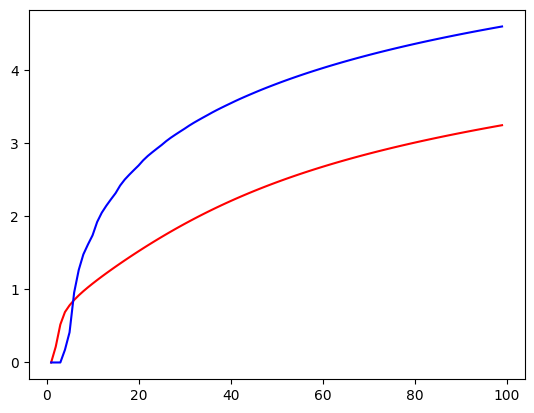

In [7]:
plt.plot(Ns, G4_mmc, color='red')
plt.plot(Ns, G20_mmc, color='blue')